In [1]:
# ============================================================
# CÉLULA 1 — SETUP PADRÃO (idêntica em todos os notebooks)
# ============================================================
import os, sys, shutil, re, glob
import numpy as np
import pandas as pd

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Detecção de ambiente
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/tcc-analise-sentimento'):
        os.system('git clone https://github.com/ROMAUSKI/tcc-analise-sentimento.git /content/tcc-analise-sentimento')
    else:
        os.system('cd /content/tcc-analise-sentimento && git pull')
    BASE_DIR = '/content/tcc-analise-sentimento'
    REAL_DATA_PATH = '/content/sample_data/dataset_real_sentimentos'
else:
    BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
    REAL_DATA_PATH = os.path.join(BASE_DIR, 'src', 'dados_reais')

# Dataset real via kagglehub (baixa só na 1ª vez)
if not os.path.exists(REAL_DATA_PATH) or not os.listdir(REAL_DATA_PATH):
    import kagglehub
    print("Baixando dataset real do Kaggle (~877 MB, só na 1ª vez)...")
    cache_path = kagglehub.dataset_download("fredericods/ptbr-sentiment-analysis-datasets")
    os.makedirs(REAL_DATA_PATH, exist_ok=True)
    for f in os.listdir(cache_path):
        shutil.copy(os.path.join(cache_path, f), os.path.join(REAL_DATA_PATH, f))
    print(f"Dataset real disponível em: {REAL_DATA_PATH}")
else:
    print(f"Dataset real já existe em: {REAL_DATA_PATH}")

# Caminhos do projeto
DADOS_BRUTOS_APPS = os.path.join(BASE_DIR, 'dados', 'brutos')
DADOS_BRUTOS_APPS   = os.path.join(BASE_DIR, 'dados', 'brutos_apps')
DADOS_PROCESSADO    = os.path.join(BASE_DIR, 'dados', 'processado')
RESULTADOS          = os.path.join(BASE_DIR, 'resultados')

print(f"Ambiente: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_DIR: {BASE_DIR}")


Dataset real já existe em: C:\Users\Davi\Documentos\tcc-analise-sentimento\src\dados_reais
Ambiente: Local
BASE_DIR: C:\Users\Davi\Documentos\tcc-analise-sentimento


# Notebook 07 — Comparativo das 5 Visões (Nicho: Apps)

Executa as cinco visões metodológicas para o nicho de aplicativos (UTLC-Apps):

**Volume controlado (200 frases/classe):**
- **V1: Sintético → Sintético** — baseline sintético isolado
- **V2: Real → Real** — baseline real com volume comparável
- **V3: Sintético → Real** — *cross-domain controlado* (mesmo test set do V2)

**Volume natural (todos os dados reais):**
- **V4: Real → Real (desbalanceado)** — limite superior do real com dado abundante
- **V5: Sintético → Real (desbalanceado)** — *cross-domain "vida real"* (mesmo test set do V4)

**Pareamentos:** V2↔V3 isola fonte com volume controlado; V4↔V5 isola fonte com volume natural; V2↔V4 mostra ganho de volume.

**Métricas reportadas:** Acurácia, Precisão, Recall, F1 weighted, **F1 macro** (importante para V4/V5 desbalanceadas).

**Saída final (última célula):** `metricas_5_visoes_apps.csv` + gráficos em `resultados/`.

## 1. Carregar dataset sintético (200 frases/classe)

In [2]:
# ============================================================
# CÉLULA 3 — Carregar dataset sintético (Movies) e limpar
# ============================================================
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-zà-ÿ\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Lê o synthetic_dataset_apps.csv já gerado pelo notebook 01
df_sintetico = pd.read_csv(os.path.join(DADOS_PROCESSADO, 'synthetic_dataset_apps.csv'))
df_sintetico = df_sintetico[['frase_limpa', 'classe', 'fonte']].dropna()

# Balanceia para 600 frases por classe = sintético inteiro (1800 total)
# Decisão 2026-05-10: usar todo o sintético gerado e balancear real igual
N_POR_CLASSE = 600
df_sintetico_bal = (df_sintetico
                    .groupby('classe')
                    .sample(n=N_POR_CLASSE, random_state=SEED)
                    .reset_index(drop=True))

print(f"Sintético balanceado: {len(df_sintetico_bal)} frases ({N_POR_CLASSE}/classe)")
print(df_sintetico_bal['classe'].value_counts())


Sintético balanceado: 1800 frases (600/classe)
classe
Negativa    600
Neutra      600
Positiva    600
Name: count, dtype: int64


## 2. Carregar dataset real, mapear rating→classe e balancear (200 frases/classe)

In [3]:
# ============================================================
# CÉLULA 4 — Carregar dataset real (Movies), mapear rating→3 classes, balancear
# ============================================================
path_real = os.path.join(REAL_DATA_PATH, 'utlc_apps.csv')

# Carrega só uma fração para evitar travamento (100k linhas é suficiente)
df_real_raw = pd.read_csv(path_real, nrows=100000)

# Mapping rating → 3 classes (essencial: dataset nativo só tem polaridade binária)
def rating_para_classe(rating):
    if rating >= 4: return 'Positiva'   # 4-5 estrelas
    elif rating <= 2: return 'Negativa' # 1-2 estrelas
    else: return 'Neutra'               # 3 estrelas

df_real_raw['classe'] = df_real_raw['rating'].apply(rating_para_classe)
df_real = df_real_raw[['review_text', 'classe']].dropna().rename(columns={'review_text': 'frase'})
df_real['frase_limpa'] = df_real['frase'].apply(limpar_texto)
df_real = df_real[df_real['frase_limpa'] != ''].reset_index(drop=True)

# Balanceia para 200 frases por classe (mesmo volume do sintético → comparação justa)
df_real_bal = (df_real
               .groupby('classe')
               .sample(n=N_POR_CLASSE, random_state=SEED)
               .reset_index(drop=True))

print(f"Real balanceado: {len(df_real_bal)} frases ({N_POR_CLASSE}/classe)")
print(df_real_bal['classe'].value_counts())


Real balanceado: 1800 frases (600/classe)
classe
Negativa    600
Neutra      600
Positiva    600
Name: count, dtype: int64


## 2b. Carregar dataset real DESBALANCEADO (todos os dados, distribuição natural)

In [4]:
# ============================================================
# Carregar dataset real SEM balancear (V4 e V5 usam este)
# ============================================================
# Reusa df_real (já carregado na célula 4 com mapping rating->classe e limpeza)
# A diferença para df_real_bal é que NÃO sub-amostramos para 200/classe
df_real_desbal = df_real.copy().reset_index(drop=True)

print(f'Real desbalanceado: {len(df_real_desbal)} frases')
print('Distribuição natural das classes:')
print(df_real_desbal['classe'].value_counts())
print('Proporção (%):')
print((df_real_desbal['classe'].value_counts(normalize=True) * 100).round(2))


Real desbalanceado: 99758 frases
Distribuição natural das classes:
classe
Positiva    70602
Neutra      19927
Negativa     9229
Name: count, dtype: int64
Proporção (%):
classe
Positiva    70.77
Neutra      19.98
Negativa     9.25
Name: proportion, dtype: float64


## 3. Função genérica `run_vision(...)` — TF-IDF + 3 modelos

In [5]:
# ============================================================
# Função genérica para executar uma visão (com F1 macro)
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
from sklearn.model_selection import train_test_split

def run_vision(X_train, y_train, X_test, y_test, visao_nome):
    modelos = {
        'Naive Bayes': MultinomialNB(),
        'Regressão Logística': LogisticRegression(random_state=SEED, max_iter=1000),
        'SVM Linear': LinearSVC(random_state=SEED, max_iter=5000),
    }
    # max_features=5000 para conter memória/tempo nas visões desbalanceadas (~80k frases)
    tfidf = TfidfVectorizer(max_features=5000)
    X_tr = tfidf.fit_transform(X_train)
    X_te = tfidf.transform(X_test)

    rows = []
    print(f'\n--- {visao_nome} ---')
    for nome, clf in modelos.items():
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1w, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0)
        f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        print(f'  {nome:22s} F1w={f1w:.2%}  F1macro={f1m:.2%}  Acc={acc:.2%}')
        rows.append({'Visão': visao_nome, 'Modelo': nome,
                     'Acurácia': acc, 'Precisão': prec, 'Recall': rec,
                     'F1-Score': f1w, 'F1-Macro': f1m})
    return rows


## 4. Executar V1, V2, V3 (volume controlado — 200/classe)

In [6]:
# ============================================================
# Executar as 3 visões (V1=Sintético, V2=Real, V3=Cross)
# ============================================================
# Splits 80/20 estratificados
S_tr, S_te = train_test_split(df_sintetico_bal, test_size=0.2, stratify=df_sintetico_bal['classe'], random_state=SEED)
R_tr, R_te = train_test_split(df_real_bal,      test_size=0.2, stratify=df_real_bal['classe'],      random_state=SEED)

print(f'V1 treina com {len(S_tr)} sinteticas, testa em {len(S_te)} sinteticas')
print(f'V2 treina com {len(R_tr)} reais, testa em {len(R_te)} reais')
print(f'V3 treina com {len(S_tr)} sinteticas, testa nas MESMAS {len(R_te)} reais do V2')

todos_resultados = []
todos_resultados += run_vision(S_tr['frase_limpa'], S_tr['classe'],
                                S_te['frase_limpa'], S_te['classe'],
                                'V1: Sintético → Sintético')
todos_resultados += run_vision(R_tr['frase_limpa'], R_tr['classe'],
                                R_te['frase_limpa'], R_te['classe'],
                                'V2: Real → Real')
# V3 reusa o test set do V2 — comparação direta isolando a fonte do treino
todos_resultados += run_vision(S_tr['frase_limpa'], S_tr['classe'],
                                R_te['frase_limpa'], R_te['classe'],
                                'V3: Sintético → Real')


V1 treina com 1440 sinteticas, testa em 360 sinteticas
V2 treina com 1440 reais, testa em 360 reais
V3 treina com 1440 sinteticas, testa nas MESMAS 360 reais do V2

--- V1: Sintético → Sintético ---
  Naive Bayes            F1w=88.07%  F1macro=88.07%  Acc=88.06%
  Regressão Logística    F1w=86.93%  F1macro=86.93%  Acc=86.94%
  SVM Linear             F1w=88.33%  F1macro=88.33%  Acc=88.33%

--- V2: Real → Real ---
  Naive Bayes            F1w=52.10%  F1macro=52.10%  Acc=51.67%
  Regressão Logística    F1w=54.45%  F1macro=54.45%  Acc=54.44%


  SVM Linear             F1w=54.80%  F1macro=54.80%  Acc=55.00%

--- V3: Sintético → Real ---
  Naive Bayes            F1w=34.75%  F1macro=34.75%  Acc=38.89%
  Regressão Logística    F1w=38.77%  F1macro=38.77%  Acc=40.00%
  SVM Linear             F1w=36.45%  F1macro=36.45%  Acc=38.06%


## 4b. Executar V4 e V5 (volume natural — todos os reais)

V4: Real desbalanceado → Real desbalanceado (split 80/20 estratificado)  
V5: Sintético (200/classe, mesmo treino do V3) → **mesmo test set do V4** (~20k frases reais)

*Atenção: pode levar 1-2 min por causa do volume.*

In [7]:
# ============================================================
# Executar V4 e V5 — desbalanceadas, volume natural
# ============================================================
# Split 80/20 estratificado no real desbalanceado
RD_tr, RD_te = train_test_split(
    df_real_desbal, test_size=0.2, stratify=df_real_desbal['classe'], random_state=SEED)

print(f'V4 treina com {len(RD_tr)} reais, testa em {len(RD_te)} reais (desbalanceado)')
print(f'V5 treina com {len(S_tr)} sintéticas (mesmo treino do V3), testa nas MESMAS {len(RD_te)} reais do V4')

todos_resultados += run_vision(RD_tr['frase_limpa'], RD_tr['classe'],
                                RD_te['frase_limpa'], RD_te['classe'],
                                'V4: Real → Real (desbalanceado)')

todos_resultados += run_vision(S_tr['frase_limpa'], S_tr['classe'],
                                RD_te['frase_limpa'], RD_te['classe'],
                                'V5: Sintético → Real (desbalanceado)')


V4 treina com 79806 reais, testa em 19952 reais (desbalanceado)
V5 treina com 1440 sintéticas (mesmo treino do V3), testa nas MESMAS 19952 reais do V4



--- V4: Real → Real (desbalanceado) ---
  Naive Bayes            F1w=64.36%  F1macro=38.48%  Acc=72.71%


  Regressão Logística    F1w=70.93%  F1macro=52.05%  Acc=74.72%


  SVM Linear             F1w=70.59%  F1macro=51.92%  Acc=74.40%



--- V5: Sintético → Real (desbalanceado) ---
  Naive Bayes            F1w=47.11%  F1macro=32.29%  Acc=42.42%
  Regressão Logística    F1w=45.30%  F1macro=32.61%  Acc=39.99%


  SVM Linear             F1w=45.47%  F1macro=32.50%  Acc=40.19%


## 5. Resultado final → tabela + gráfico (5 visões × 4 métricas) salvos para o artigo


=== MÉTRICAS COMPLETAS — Nicho: Movies (5 visões) ===
                                                          Acurácia  Precisão  Recall  F1-Score  F1-Macro
Visão                                Modelo                                                             
V1: Sintético → Sintético            Naive Bayes             88.06     88.11   88.06     88.07     88.07
                                     Regressão Logística     86.94     87.01   86.94     86.93     86.93
                                     SVM Linear              88.33     88.36   88.33     88.33     88.33
V2: Real → Real                      Naive Bayes             51.67     53.58   51.67     52.10     52.10
                                     Regressão Logística     54.44     54.48   54.44     54.45     54.45
                                     SVM Linear              55.00     54.66   55.00     54.80     54.80
V3: Sintético → Real                 Naive Bayes             38.89     33.57   38.89     34.75     34.75


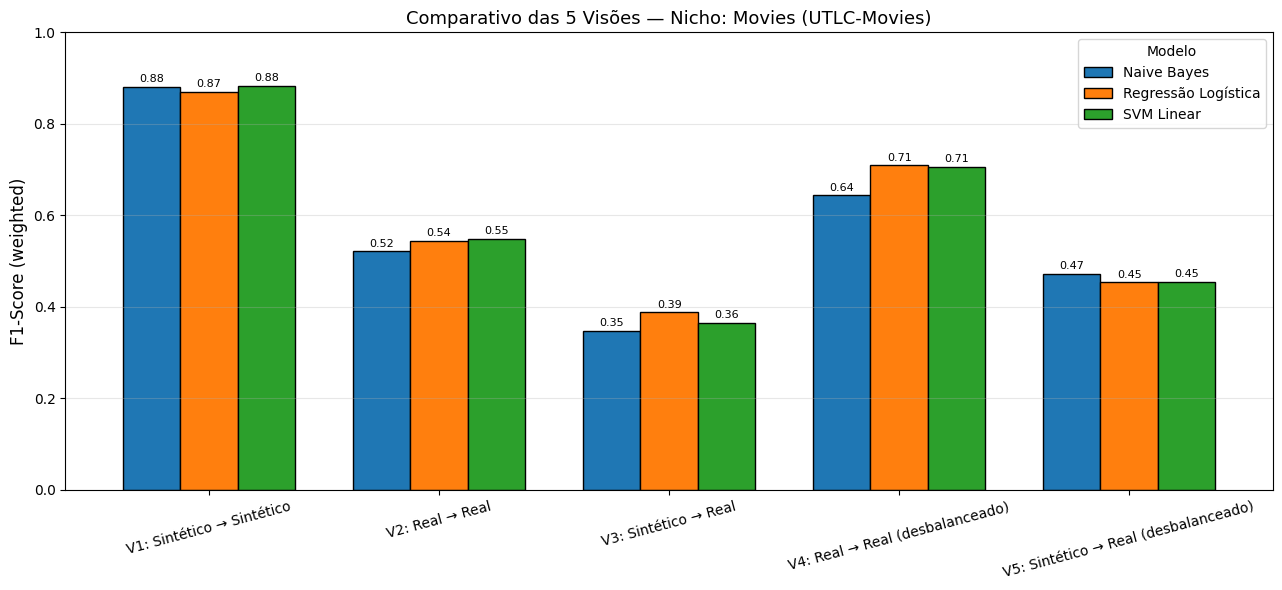

Gráfico principal salvo: C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies.png


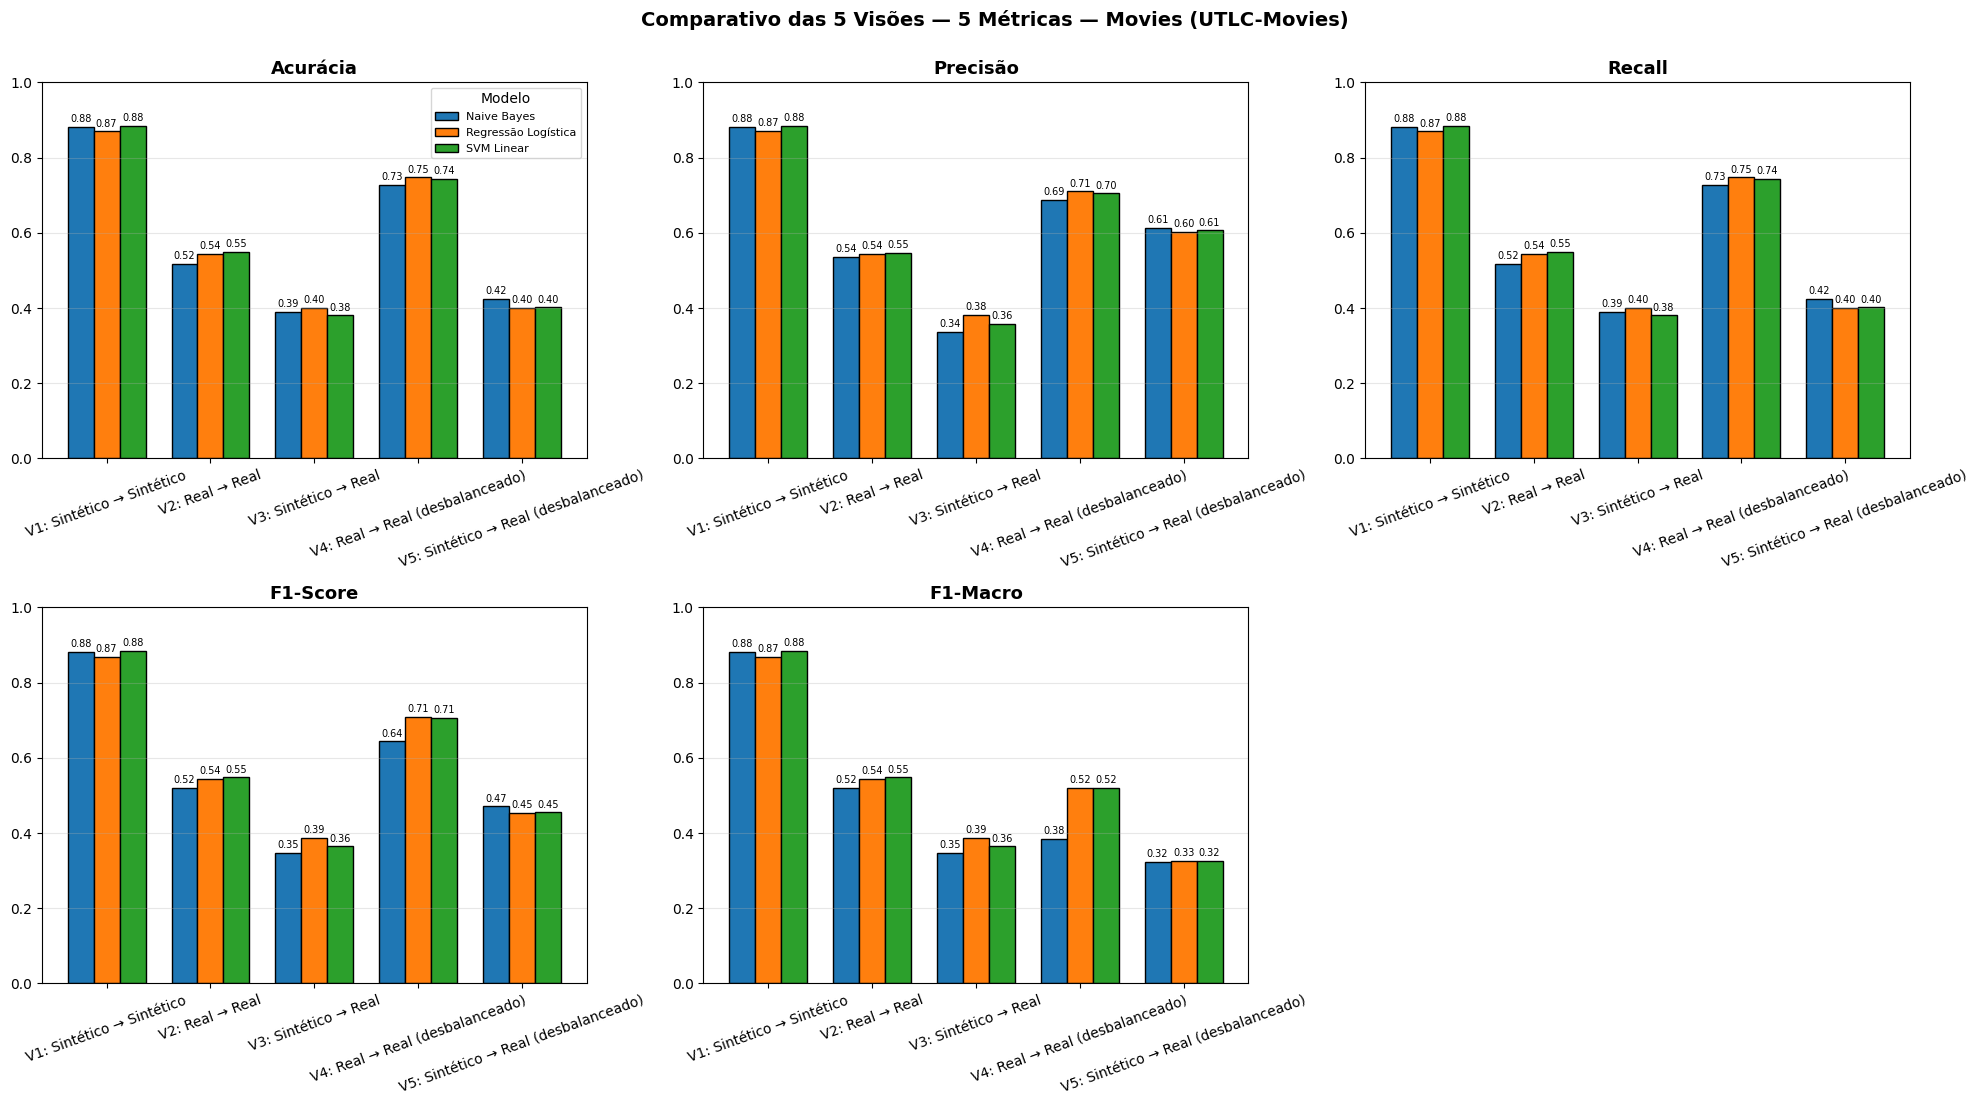

Painel 2x3 salvo: C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_5metricas.png


  - C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_acuracia.png


  - C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_precisao.png


  - C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_recall.png


  - C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_f1score.png


  - C:\Users\Davi\Documentos\tcc-analise-sentimento\resultados\grafico_5_visoes_movies_f1macro.png


In [8]:
# ============================================================
# RESULTADO FINAL: tabela + gráficos (5 visões × 5 métricas)
# ============================================================
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(todos_resultados)

# Ordem fixa das visões na tabela e nos gráficos
ordem_visoes = [
    'V1: Sintético → Sintético',
    'V2: Real → Real',
    'V3: Sintético → Real',
    'V4: Real → Real (desbalanceado)',
    'V5: Sintético → Real (desbalanceado)',
]
df_resultados['Visão'] = pd.Categorical(df_resultados['Visão'], categories=ordem_visoes, ordered=True)
df_resultados = df_resultados.sort_values(['Visão', 'Modelo']).reset_index(drop=True)

ordem_modelos = ['Naive Bayes', 'Regressão Logística', 'SVM Linear']
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'F1-Macro']

# Tabela completa
print('\n=== MÉTRICAS COMPLETAS — Nicho: Apps (5 visões) ===')
print((df_resultados.set_index(['Visão', 'Modelo'])[metricas] * 100).round(2).to_string())

# Salva CSV
os.makedirs(RESULTADOS, exist_ok=True)
csv_path = os.path.join(RESULTADOS, 'metricas_5_visoes_apps.csv')
df_resultados.round(4).to_csv(csv_path, index=False)
print(f'\nCSV salvo: {csv_path}')


# --- Gráfico principal: F1-Score (weighted) com 5 colunas ---
pivot_f1 = df_resultados.pivot(index='Visão', columns='Modelo', values='F1-Score')[ordem_modelos]
fig, ax = plt.subplots(figsize=(13, 6))
pivot_f1.plot(kind='bar', ax=ax, rot=15, edgecolor='black', width=0.75)
ax.set_ylabel('F1-Score (weighted)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Comparativo das 5 Visões — Nicho: Apps (UTLC-Apps)', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(title='Modelo', loc='upper right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
png_path = os.path.join(RESULTADOS, 'grafico_5_visoes_apps.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico principal salvo: {png_path}')

# --- Painel 2x3 com as 5 métricas ---
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for i, metrica in enumerate(metricas):
    pivot = df_resultados.pivot(index='Visão', columns='Modelo', values=metrica)[ordem_modelos]
    pivot.plot(kind='bar', ax=axes[i], rot=20, edgecolor='black', width=0.75, legend=(i==0))
    axes[i].set_title(metrica, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(axis='y', alpha=0.3)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', padding=2, fontsize=7)
    if i == 0:
        axes[i].legend(title='Modelo', loc='upper right', fontsize=8)
axes[5].set_visible(False)  # Esconde o 6º slot (vazio)
fig.suptitle('Comparativo das 5 Visões — 5 Métricas — Apps (UTLC-Apps)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
png_painel = os.path.join(RESULTADOS, 'grafico_5_visoes_apps_5metricas.png')
plt.savefig(png_painel, dpi=150, bbox_inches='tight')
plt.show()
print(f'Painel 2x3 salvo: {png_painel}')

# --- Gráficos individuais por métrica ---
for metrica in metricas:
    pivot = df_resultados.pivot(index='Visão', columns='Modelo', values=metrica)[ordem_modelos]
    fig, ax = plt.subplots(figsize=(13, 6))
    pivot.plot(kind='bar', ax=ax, rot=15, edgecolor='black', width=0.75)
    ax.set_ylabel(metrica + ' (weighted)' if metrica == 'F1-Score' else metrica, fontsize=12)
    ax.set_xlabel('')
    ax.set_title(f'{metrica} — 5 Visões — Apps (UTLC-Apps)', fontsize=13)
    ax.set_ylim(0, 1.0)
    ax.legend(title='Modelo', loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
    plt.tight_layout()
    slug = (metrica.lower()
            .replace('á','a').replace('í','i').replace('ã','a').replace('-','').replace(' ',''))
    pi = os.path.join(RESULTADOS, f'grafico_5_visoes_apps_{slug}.png')
    plt.savefig(pi, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  - {pi}')


## 💾 Backup automático (Colab → download zip)

Se rodando no Colab, comprime `resultados/` em zip e baixa pro PC.
Se rodando local, não faz nada (arquivos já estão no disco).

**Sempre rode esta célula ANTES de fechar o Colab** — senão você perde tudo.

In [ ]:
# ============================================================
# CÉLULA FINAL — Backup automático Colab → download
# Local: no-op | Colab: zip + download de resultados/
# ============================================================
if 'IN_COLAB' not in globals():
    # Fallback: detecta de novo caso a célula 1 não tenha definido (raro)
    import sys
    IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import shutil, time
    from google.colab import files

    if 'RESULTADOS' not in globals():
        RESULTADOS = '/content/tcc-analise-sentimento/resultados'

    timestamp = time.strftime('%Y%m%d_%H%M%S')
    nome_zip = f'resultados_colab_{timestamp}'
    zip_path = shutil.make_archive(f'/content/{nome_zip}', 'zip', RESULTADOS)
    print(f'✓ Comprimido: {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)')
    print('✓ Iniciando download... (descompacte em resultados/ no PC local)')
    files.download(zip_path)
else:
    print(f'Ambiente local — resultados já estão em: {RESULTADOS if "RESULTADOS" in globals() else "resultados/"}')
    print('Nenhuma ação necessária.')
